# **Optimizing Global Contrastive Loss with SogCLR and Cosine Gamma Schedule**

**Author**: Xiyuan Wei, Tianbao Yang  



**Introduction**

In this tutorial, we compare the performance of SogCLR algorithm using cosine $\gamma$ decay schedule and constant schedule in a typical bimodal contrastive learning task. Previous algorithms optimizing the Global Contrastive Loss family (e.g., SogCLR and iSogCLR) sets $\gamma$ to a constant. In this tutorial, we compare the constant schedule with a cosine decay schedule: let $e$ be the current epoch, $E$ be the number of decay epochs and $\gamma_{\mathrm{min}}$ be the final value, then the value of $\gamma$ at this epoch is given by
$$\gamma = (1.0- \gamma_{\mathrm{min}}) * 0.5 * \cos(\pi * e / E) + \gamma_{\mathrm{min}}.$$
Here $E$ is not necessarily equal to the number of training epochs, we recommend to set it to half of the number of training epochs. If $e> E$, then $\gamma$ is set to $\gamma_{\mathrm{min}}$.

In pretraining stage, we use a subset of the [CC3M dataset](https://ai.google.com/research/ConceptualCaptions/download), which contains about 300,000 image-text pairs. And then we evaluate the pretrained models via zero-shot image/text retrieval on [MS-COCO](https://github.com/tylin/coco-caption) dataset. We provide the metadata of the training subset and evluation set [here](https://drive.google.com/drive/folders/1ByPrsBhhjz8463qCuLuNlacSPLc8x9OL?usp=sharing). This tutorial is forked from the [iSogCLR](https://docs.libauc.org/examples/isogclr.html) tutorial.

The experiment in this tutorial is conducted one 4 Nvidia A30 GPUs, you can modify the **CUDA_VISIBLE_DEVICES** option and **batch_size_train** option based on your equipments.


**Reference**

 If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065).

# **Importing required libs**

In [ ]:
!pip install -U libauc
!pip install timm
!pip install transformers

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["CUDA_VISIBLE_DEVICES"] = '6,7,8,9' # distributed training: '0,1,2,3'

import re
import argparse
from pathlib import Path
import json
import os
import random
import math
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch import optim
import torchvision
from torchvision import transforms

from torch.utils.data import Dataset, Subset, DataLoader

from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None

import cv2
import numpy as np

import timm
from transformers import AutoModel, AutoTokenizer

import libauc
from libauc.losses.contrastive import GCLoss_v2
from libauc.optimizers import SogCLR
from libauc.utils.paper_utils import CosineLRScheduler

/data/xwei/programs/miniconda3/envs/fedssl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Arguments for experiments**

In [ ]:
# path to data folder
data_path = './datasets/cc3m'
train_file = 'cc3m_subset_new.json'

# model config
image_encoder = 'resnet50'
text_encoder = 'distilbert-base-uncased'
image_res = 256
vision_width = 768
embed_dim = 256
seed = 42

# optimizer and schedular
opt = 'adamW'
lr = 3e-4
min_lr = 1e-5
warmup = True
warmup_lr = 1e-5
weight_decay = 0.02
decay_rate = 1
epochs = 30
warmup_epochs = 20
cooldown_epochs = 0

# training & test settings
batch_size_train = 256
batch_size_test = 512
k_test = 256

# output path
output_dir = './output/'

# AMP training
use_amp = True

# loss config
temp = 0.01       # the temperature parameter for clip or sogclr

n_gpus = torch.cuda.device_count()

val_coco_file = 'coco_val_new.json'
test_coco_file = 'coco_test_new.json'
coco_image_root = './datasets/coco'

Path(output_dir).mkdir(parents=True, exist_ok=True)

# **Define helper functions**

In [ ]:
# we employ this function to preprocess the captions

def pre_caption(caption, max_words):
    caption = re.sub(
        r"([,.'!?\"()*#:;~])",
        '',
        caption.lower(),
    ).replace('-', ' ').replace('/', ' ').replace('<person>', 'person')

    caption = re.sub(
        r"\s{2,}",
        ' ',
        caption,
    )
    caption = caption.rstrip('\n')
    caption = caption.strip(' ')

    #truncate caption
    caption_words = caption.split(' ')
    if len(caption_words)>max_words:
        caption = ' '.join(caption_words[:max_words])

    return caption

In [ ]:
class train_set(Dataset):
    def __init__(self, ann_file, transform, image_root, max_words=30):
        self.ann = []
        for f in ann_file:
            self.ann += json.load(open(f,'r'))
        self.transform = transform
        self.image_root = image_root
        self.max_words = max_words
        self.img_ids = {}

        n = 0
        for ann in self.ann:
            img_id = ann['image_id']
            if img_id not in self.img_ids.keys():
                self.img_ids[img_id] = n
                n += 1

    def __len__(self):
        return len(self.ann)

    def __getitem__(self, index):
        ann = self.ann[index]
        # image_path = os.path.join(self.image_root, ann['image'])
        image_path =  ann['image']

        image = Image.open(image_path).convert('RGB')
        image = self.transform(image)

        caption = pre_caption(ann['caption'], self.max_words)

        return image, caption, self.img_ids[ann['image_id']], index


class eval_set(Dataset):
    def __init__(self, ann_file, transform, image_root, max_words=30):
        self.ann = json.load(open(ann_file,'r'))
        self.transform = transform
        self.image_root = image_root
        self.max_words = max_words

        self.text = []
        self.image = []
        self.txt2img = {}
        self.img2txt = {}

        txt_id = 0
        for img_id, ann in enumerate(self.ann):
            self.image.append(ann['image'])
            self.img2txt[img_id] = []
            # 'val2014/000000184613.jpg'
            image_path = os.path.join(self.image_root, ann['image'].split('/')[0], f"COCO_val2014_{ann['image'].split('/')[-1]}")
            ann['image'] = image_path
            for i, caption in enumerate(ann['caption']):
                self.text.append(pre_caption(caption,self.max_words))
                self.img2txt[img_id].append(txt_id)
                self.txt2img[txt_id] = img_id
                txt_id += 1

    def __len__(self):
        return len(self.image)

    def __getitem__(self, index):
        image_path = self.ann[index]['image']
        image = Image.open(image_path).convert('RGB')
        image = self.transform(image)

        return image, index

In [ ]:
def add_weight_decay(model, weight_decay=1e-5, skip_list=()):
    decay = []
    no_decay = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue  # frozen weights
        if len(param.shape) == 1 or name.endswith(".bias") or name in skip_list:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': no_decay, 'weight_decay': 0.},
        {'params': decay, 'weight_decay': weight_decay}]


def create_optimizer(model, opt, weight_decay=1e-5, filter_bias_and_bn=True):
    if weight_decay and filter_bias_and_bn:
        skip = {}
        if hasattr(model, 'no_weight_decay'):
            skip = model.no_weight_decay()
        parameters = add_weight_decay(model, weight_decay, skip)
        weight_decay = 0.
    else:
        parameters = model.parameters()

    opt_args = dict(lr=lr, weight_decay=weight_decay)
    optimizer = SogCLR(parameters, mode=opt, **opt_args)

    return optimizer

In [ ]:
def create_scheduler(optimizer):
    num_epochs = epochs

    lr_scheduler = CosineLRScheduler(
        optimizer,
        t_initial = num_epochs,
        t_mul = 1.0,
        lr_min = min_lr,
        decay_rate = decay_rate,
        warmup_lr_init = warmup_lr,
        warmup_t = warmup_epochs,
        cycle_limit = 1,
        t_in_epochs = True,
        noise_range_t = None,
        noise_pct = 0.67,
        noise_std = 1.0,
        noise_seed = 42,
    )

    return lr_scheduler

# **Reproducibility**

The following functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs.

In [ ]:
# fix the seed for reproducibility
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
cudnn.benchmark = True

# **Building the model**

In [ ]:
# The following class includes the image encoder, text encoder and several objectives
class Model(nn.Module):
    def __init__(self, image_encoder = None, text_encoder = None,
                 embed_dim = 256, init_model = True, bsz = 128,
                 gamma = 0.9,         # the coefficient for moving average estimator
                 temp = 0.01,         # temperature for clip or sogclr
                 gamma_schedule = 'cosine',
                 gamma_decay_epochs = 1,
                ):
        super().__init__()

        self.temp = temp

        self.visual_encoder = timm.create_model(image_encoder, pretrained=init_model)
        self.visual_encoder.reset_classifier(0)

        self.text_encoder = AutoModel.from_pretrained(text_encoder, local_files_only=False)

        if not init_model:
            self.text_encoder.init_weights()

        self.vision_proj = nn.Linear(self.visual_encoder.num_features, embed_dim)
        self.text_proj = nn.Linear(768, embed_dim)

        self.criterion = GCLoss_v2(tau=temp, gamma=gamma, enable_isogclr=False,
                                   gamma_schedule=gamma_schedule, gamma_decay_epochs=gamma_decay_epochs)

    def forward(self, image, text_ids, text_att_masks, idx, text_idx, epoch):
        image_embeds = self.visual_encoder(image)
        image_embeds = self.vision_proj(image_embeds)
        image_feat = F.normalize(image_embeds, dim=-1)

        text_output = self.text_encoder(text_ids, attention_mask=text_att_masks, output_hidden_states=False)
        text_embeds = self.text_proj(text_output.last_hidden_state[:,0,:])
        text_feat = F.normalize(text_embeds, dim=-1)

        loss, info = self.criterion(image_feat, text_feat, idx)

        return loss, info

# **Training functions**

In [ ]:
print_freq = 50 # user can determine how many iterations to output (e.g., 50 by default)

In [ ]:
def epoch_train(model, data_loader, optimizer, tokenizer, epoch, max_epoch, warmup_steps, device, scheduler, grad_scaler):
    # train
    model.train()

    step_size = 100
    warmup_iterations = warmup_steps * step_size

    if hasattr(model, 'module'):
        model_orig = model.module
    else:
        model_orig = model
    # adjust gamma based on gamma schedule
    if hasattr(model_orig.criterion, 'adjust_gamma'):
        model_orig.criterion.adjust_gamma(epoch)

    for i,(image, text, idx, text_idx) in enumerate(data_loader):
        optimizer.zero_grad()

        image = image.to(device, non_blocking=True)
        idx = idx.to(device, non_blocking=True)
        text_idx = text_idx.to(device, non_blocking=True)
        text_input = tokenizer(text, padding='max_length', truncation=True, max_length=30, return_tensors="pt").to(device)

        if grad_scaler is None:
            loss, info = model(image, text_input.input_ids, text_input.attention_mask, idx=idx, text_idx=text_idx, epoch=epoch)
            loss.mean().backward()
            optimizer.step()
        else:
            with torch.cuda.amp.autocast():
                loss, info = model(image, text_input.input_ids, text_input.attention_mask, idx=idx, text_idx=text_idx, epoch=epoch)
            grad_scaler.scale(loss.mean()).backward()
            grad_scaler.step(optimizer)
            grad_scaler.update()

        if epoch==0 and i%step_size==0 and i<=warmup_iterations:
            scheduler.step(i//step_size)

        if i%print_freq == 0:
            lr = optimizer.param_groups[0]["lr"]
            print("Epoch:", epoch, "iteration:", i, "lr:", lr, "loss:", loss.mean().item())
            if info is not None:
                print("tau_img: %.4f, tau_txt: %.4f" % (info[0].mean(), info[1].mean()))

# **Evaluation functions**

In [ ]:
@torch.no_grad()
def evaluation(model, data_loader, tokenizer, device):
    # test
    model.eval()

    print('Computing features for evaluation...')
    texts = data_loader.dataset.text
    num_text = len(texts)
    text_bs = 256
    text_embeds = []
    for i in range(0, num_text, text_bs):
        text = texts[i: min(num_text, i+text_bs)]
        text_input = tokenizer(text, padding='max_length', truncation=True, max_length=30, return_tensors="pt").to(device)
        text_output = model.text_encoder(text_input.input_ids, attention_mask=text_input.attention_mask, output_hidden_states=False)
        text_embed = F.normalize(model.text_proj(text_output.last_hidden_state[:,0,:]), dim=-1)
        text_embeds.append(text_embed)
    text_embeds = torch.cat(text_embeds,dim=0)

    image_embeds = []
    for image, img_id in data_loader:
        image = image.to(device)
        image_feat = model.visual_encoder(image)
        image_embed = model.vision_proj(image_feat)
        image_embed = F.normalize(image_embed, dim=-1)
        image_embeds.append(image_embed)
    image_embeds = torch.cat(image_embeds,dim=0)

    sims_matrix = image_embeds @ text_embeds.t()
    score_matrix_i2t = torch.full((len(data_loader.dataset.image),len(texts)),-100.0).to(device)

    for i,sims in enumerate(sims_matrix):
        topk_sim, topk_idx = sims.topk(k=k_test, dim=0)
        score_matrix_i2t[i, topk_idx] = topk_sim

    sims_matrix = sims_matrix.t()
    score_matrix_t2i = torch.full((len(texts),len(data_loader.dataset.image)),-100.0).to(device)

    for i,sims in enumerate(sims_matrix):
        topk_sim, topk_idx = sims.topk(k=k_test, dim=0)
        score_matrix_t2i[i, topk_idx] = topk_sim

    return score_matrix_i2t.cpu().numpy(), score_matrix_t2i.cpu().numpy()



@torch.no_grad()
def itm_eval(scores_i2t, scores_t2i, txt2img, img2txt):

    #Images->Text
    ranks = np.zeros(scores_i2t.shape[0])
    for index,score in enumerate(scores_i2t):
        inds = np.argsort(score)[::-1]
        # Score
        rank = 1e20
        for i in img2txt[index]:
            tmp = np.where(inds == i)[0][0]
            if tmp < rank:
                rank = tmp
        ranks[index] = rank

    # Compute metrics
    tr1 = 100.0 * len(np.where(ranks < 1)[0]) / len(ranks)
    tr5 = 100.0 * len(np.where(ranks < 5)[0]) / len(ranks)
    tr10 = 100.0 * len(np.where(ranks < 10)[0]) / len(ranks)

    #Text->Images
    ranks = np.zeros(scores_t2i.shape[0])

    for index,score in enumerate(scores_t2i):
        inds = np.argsort(score)[::-1]
        ranks[index] = np.where(inds == txt2img[index])[0][0]

    # Compute metrics
    ir1 = 100.0 * len(np.where(ranks < 1)[0]) / len(ranks)
    ir5 = 100.0 * len(np.where(ranks < 5)[0]) / len(ranks)
    ir10 = 100.0 * len(np.where(ranks < 10)[0]) / len(ranks)

    tr_mean = (tr1 + tr5 + tr10) / 3
    ir_mean = (ir1 + ir5 + ir10) / 3
    r_mean = (tr_mean + ir_mean) / 2

    eval_result =  {'txt_r1': tr1,
                    'txt_r5': tr5,
                    'txt_r10': tr10,
                    'txt_r_mean': tr_mean,
                    'img_r1': ir1,
                    'img_r5': ir5,
                    'img_r10': ir10,
                    'img_r_mean': ir_mean,
                    'r_mean': r_mean}
    return eval_result

# **Dataset Pipeline for Bimodal Contrastive Learning**

In [ ]:
# set up the transformation, datasets and dataloaders
train_transform = transforms.Compose([
        transforms.RandomResizedCrop(image_res, scale=(0.5, 1.0), interpolation=Image.BICUBIC),
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(),
        transforms.ToTensor(),
        transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
    ])

test_transform = transforms.Compose([
    transforms.Resize((image_res, image_res), interpolation=Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
    ])

train_dataset = train_set([train_file], train_transform, data_path)
val_coco_dataset = eval_set(val_coco_file, test_transform, coco_image_root)
test_coco_dataset = eval_set(test_coco_file, test_transform, coco_image_root)

print("len of train_dataset:", len(train_dataset))
print("len of coco val/test:", len(val_coco_dataset), len(test_coco_dataset))

train_loader = DataLoader(train_dataset, batch_size=batch_size_train * n_gpus, num_workers=16, pin_memory=True,
                         shuffle=True, drop_last=True, prefetch_factor=4)
val_loader = DataLoader(val_coco_dataset, batch_size=batch_size_test, num_workers=16, pin_memory=True,
                       shuffle=False, drop_last=False, prefetch_factor=12)
test_loader = DataLoader(test_coco_dataset, batch_size=batch_size_test, num_workers=16, pin_memory=True,
                       shuffle=False, drop_last=False, prefetch_factor=12)

len of train_dataset: 293329
len of coco val/test: 5000 5000


# **Pretraining and evaluation for SogCLR with Cosine Gamma**

For consine gamma schedule, we recommend setting **gamma_decay_epochs** to 50% of the number of training epochs.

In [ ]:
gamma = 0.2       # the parameter for the moving average estimator in sogclr/isogclr
gamma_schedule = "cosine"
gamma_decay_epochs = epochs // 2

# create the model and wrap it in DDP
tokenizer = AutoTokenizer.from_pretrained(text_encoder, local_files_only=False)
model = Model(image_encoder=image_encoder, text_encoder=text_encoder, embed_dim=embed_dim,
              init_model=True, bsz=batch_size_train, gamma=gamma, temp=temp,
              gamma_schedule=gamma_schedule, gamma_decay_epochs=gamma_decay_epochs)

model = model.cuda()

Using cosine schedule for gamma with gamma_min = 0.2, gamma_decay_epochs = 15


In [ ]:
if n_gpus > 1:
    print("Using", n_gpus, "GPUs")
    model = nn.DataParallel(model)

Using 4 GPUs


In [ ]:
# set up the optimizer and objective function
optimizer = create_optimizer(model, opt, weight_decay)
lr_scheduler = create_scheduler(optimizer)

if use_amp:
    grad_scaler = torch.cuda.amp.GradScaler()
else:
    grad_scaler = None

# training loop
for epoch in range(0, epochs):
    train_stats = epoch_train(model, train_loader, optimizer, tokenizer, epoch, epochs,
                              warmup_epochs, torch.device('cuda'), lr_scheduler, grad_scaler)

    # evaluate the model on ms-coco data
    try:
        score_val_i2t_coco, score_val_t2i_coco = evaluation(model.module, val_loader, tokenizer,  torch.device('cuda'))
        score_test_i2t_coco, score_test_t2i_coco = evaluation(model.module, test_loader, tokenizer,  torch.device('cuda'))
    except:
        # for non-distributed training
        score_val_i2t_coco, score_val_t2i_coco = evaluation(model, val_loader, tokenizer,  torch.device('cuda'))
        score_test_i2t_coco, score_test_t2i_coco = evaluation(model, test_loader, tokenizer,  torch.device('cuda'))
    print("Epoch:", epoch)
    val_result_coco = itm_eval(score_val_i2t_coco, score_val_t2i_coco, val_loader.dataset.txt2img, val_loader.dataset.img2txt)
    print("coco val:", val_result_coco)
    test_result_coco = itm_eval(score_test_i2t_coco, score_test_t2i_coco, test_loader.dataset.txt2img, test_loader.dataset.img2txt)
    print("coco test:", test_result_coco)

    lr_scheduler.step(epoch+warmup_epochs+1)

Epoch: 0, gamma: 1.000


/data/xwei/programs/miniconda3/envs/fedssl/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Epoch: 0 iteration: 0 lr: 1e-05 loss: 25.562393188476562
Epoch: 0 iteration: 50 lr: 1e-05 loss: 7.046422958374023
Epoch: 0 iteration: 100 lr: 2.45e-05 loss: 4.479846000671387
Epoch: 0 iteration: 150 lr: 2.45e-05 loss: 1.4941186904907227
Epoch: 0 iteration: 200 lr: 3.899999999999999e-05 loss: 0.7526077032089233
Epoch: 0 iteration: 250 lr: 3.899999999999999e-05 loss: 0.5853667259216309
Computing features for evaluation...
Computing features for evaluation...
Epoch: 0
coco val: {'txt_r1': 3.32, 'txt_r5': 11.82, 'txt_r10': 18.46, 'txt_r_mean': 11.200000000000001, 'img_r1': 1.5953618552578968, 'img_r5': 6.261495401839264, 'img_r10': 10.547780887644942, 'img_r_mean': 6.1348793815807, 'r_mean': 8.667439690790351}
coco test: {'txt_r1': 3.18, 'txt_r5': 11.2, 'txt_r10': 17.26, 'txt_r_mean': 10.546666666666667, 'img_r1': 1.6113554578168732, 'img_r5': 6.1975209916033585, 'img_r10': 10.735705717712914, 'img_r_mean': 6.1815273890443825, 'r_mean': 8.364097027855525}
Epoch: 1, gamma: 0.991
Epoch: 1 it

# **Visualization**

In order to compare the performance of different algorithms, we also train CLIP models using OpenCLIP and SogCLR with constant gamma. Notebooks for training CLIP models using the two algorithms are available [here](https://colab.research.google.com/drive/1Xapa9XDu9RxKCxlDwzIogHiJggil0PcL) and [here](https://colab.research.google.com/drive/1Iplab_ci13FTTfrIbEp4UtiOLTjiak6e), respectively. We plot the training curves of the mean validation recall values of the three algorithms.

In [ ]:
clip_recall_vals = [9.146024256963882, 25.643747834199658, 29.270318539250965, 30.15803545248567, 30.758616553378648, 30.071351459416235, 30.393121418099422, 30.48455817672931, 30.86781287485006, 30.960474476875916, 30.23930161268826, 30.297093162734903, 30.965095295215246, 31.358384646141545, 31.467666266826605, 30.952405704384915, 31.01773290683726, 31.05107556977209, 31.651619352259097, 31.91153405304545, 31.72560575769692, 31.692890843662532, 31.85492869518859, 32.204224976675995, 32.286870585099294, 32.64414634146342, 32.50149940023991, 32.45683726509397, 32.46283220045315, 32.77081167532987]
sogclr_const_gamma_recall_vals = [8.643449286951887, 20.795427162468346, 25.186021591363456, 27.750850326536053, 28.922504331600692, 29.124374250299883, 29.839438891110223, 29.683995735039318, 31.367840863654536, 32.42836332133814, 31.349722777555648, 32.35694388911102, 31.718447287751566, 32.2727469012395, 31.900145275223245, 32.71076636012261, 32.902112488338, 33.1586818605891, 34.02394908703185, 34.01059442889511, 33.840582433693186, 34.06315873650539, 33.859892043182725, 34.69845661735305, 34.67579101692657, 34.69047181127549, 34.87510595761695, 34.759770758363324, 34.9390737038518, 34.88375982940157]
sogclr_cosine_gamma_recall_vals = [8.667439690790351, 26.009160335865655, 29.73834332933493, 30.173495934959348, 31.42988004798081, 32.007712914834066, 32.069047047847526, 31.48698787151806, 32.637692922830865, 32.831547381047585, 33.19884846061575, 33.441436758629884, 33.83079568172731, 33.37606290817007, 33.63799147007863, 34.22860855657737, 34.905175263228045, 34.52780087964814, 34.78774223643875, 34.96900573104092, 35.57564174330268, 35.79826469412235, 35.75828202052512, 35.6609356257497, 35.89152205784353, 35.52024390243903, 35.56622950819672, 35.79489137678262, 35.858208716513396, 35.56754364920698]

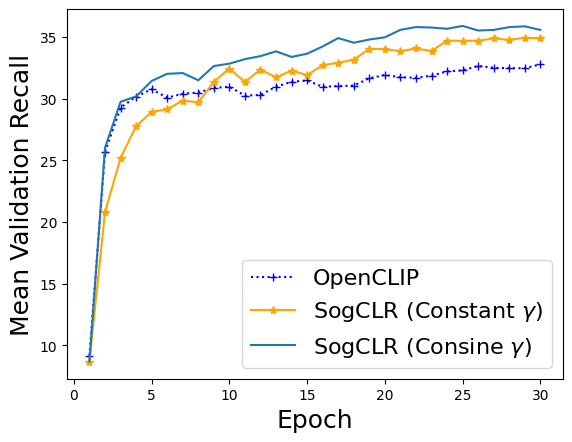

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 31)

plt.plot(epochs, clip_recall_vals, label='OpenCLIP', ls=':', marker='+', color='blue')
plt.plot(epochs, sogclr_const_gamma_recall_vals, label='SogCLR (Constant $\\gamma$)', marker='*', color='orange')
plt.plot(epochs, sogclr_cosine_gamma_recall_vals, label='SogCLR (Consine $\\gamma$)')

plt.ylabel('Mean Validation Recall', fontsize=18)
plt.xlabel('Epoch', fontsize=18)

plt.legend(fontsize=16)

plt.show()

From the above figure we can see that with constant gamma, the performance of SogCLR in early stage is worse than that of CLIP. While with cosine gamma, the performance of SogCLR is better than that of CLIP throughout training.